# **1. Understanding the Dataset**


In [4]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

In [6]:
data = pd.read_csv("/content/health_data.csv")

In [7]:
data.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


In [8]:
# Let's examine the dataset
print(data.shape)

(70000, 14)


In [11]:
# Load the Cardiovascular dataset
X = data[['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']]
y = data[['cardio']]


# **2. Data Preprocessing**

In [12]:
# Examine the data
print("\nFirst 5 rows:")
print(X.head())


First 5 rows:
       age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393.0       1   168.0    62.0  110.0   80.0            0     0      0   
1  20228.0       0   156.0    85.0  140.0   90.0            2     0      0   
2  18857.0       0   165.0    64.0  130.0   70.0            2     0      0   
3  17623.0       1   169.0    82.0  150.0  100.0            0     0      0   
4  17474.0       0   156.0    56.0  100.0   60.0            0     0      0   

   alco  active  
0     0       1  
1     0       1  
2     0       0  
3     0       1  
4     0       0  


In [13]:
# Check for missing values
print("\nMissing values:")
print(X.isnull().sum().sum())


Missing values:
0


In [14]:
# Statistical summary
print("\nStatistical summary:")
print(X.describe())


Statistical summary:
                age        gender        height        weight         ap_hi  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   19468.865814      0.349571    164.359229     74.205690    128.817286   
std     2467.251667      0.476838      8.210126     14.395757    154.011419   
min    10798.000000      0.000000     55.000000     10.000000   -150.000000   
25%    17664.000000      0.000000    159.000000     65.000000    120.000000   
50%    19703.000000      0.000000    165.000000     72.000000    120.000000   
75%    21327.000000      1.000000    170.000000     82.000000    140.000000   
max    23713.000000      1.000000    250.000000    200.000000  16020.000000   

              ap_lo   cholesterol          gluc         smoke          alco  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean      96.630414      0.366871      0.226457      0.088129      0.053771   
std      188.472530      0.68

In [44]:
# Since our dataset is already numeric, we don't need to handle categorical features

In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [20]:
# Standardize the features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (46900, 11)
Testing set shape: (23100, 11)


# **3. Model Training - Decision Tree**

In [22]:
# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [23]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

In [24]:
# Evaluate the model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

In [25]:
print("\nDecision Tree Model Evaluation:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1 Score: {dt_f1:.4f}")


Decision Tree Model Evaluation:
Accuracy: 0.6336
Precision: 0.6343
Recall: 0.6376
F1 Score: 0.6360


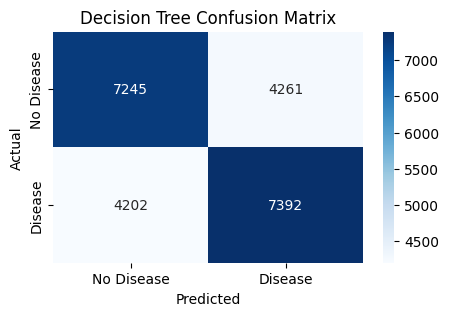

In [42]:
# Confusion Matrix
dt_cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 3))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# **4. Model Training - K-Nearest Neighbors (KNN)**

In [30]:
# Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [31]:
# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

In [32]:
# Evaluate the model
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

In [33]:
print("\nKNN Model Evaluation:")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1 Score: {knn_f1:.4f}")


KNN Model Evaluation:
Accuracy: 0.6440
Precision: 0.6506
Recall: 0.6282
F1 Score: 0.6392


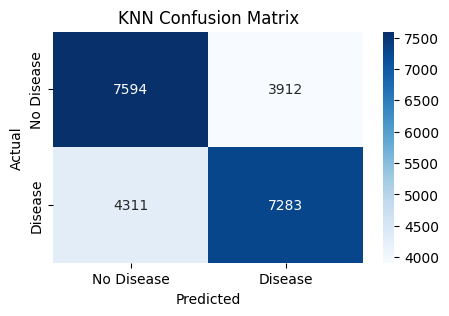

In [43]:
# Confusion Matrix
knn_cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 3))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

# **5. Model Comparison**

In [35]:
# Compare both models
print("\nModel Comparison:")
print(f"Decision Tree F1 Score: {dt_f1:.4f}")
print(f"KNN F1 Score: {knn_f1:.4f}")


Model Comparison:
Decision Tree F1 Score: 0.6360
KNN F1 Score: 0.6392


In [36]:
if dt_f1 > knn_f1:
    print("Decision Tree performs better in terms of F1 score.")
else:
    print("KNN performs better in terms of F1 score.")

KNN performs better in terms of F1 score.


In [39]:
# Classification Report for Decision Tree
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))


Decision Tree Classification Report:
              precision    recall  f1-score   support

  No Disease       0.63      0.63      0.63     11506
     Disease       0.63      0.64      0.64     11594

    accuracy                           0.63     23100
   macro avg       0.63      0.63      0.63     23100
weighted avg       0.63      0.63      0.63     23100



In [41]:
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['No Disease', 'Disease']))


KNN Classification Report:
              precision    recall  f1-score   support

  No Disease       0.64      0.66      0.65     11506
     Disease       0.65      0.63      0.64     11594

    accuracy                           0.64     23100
   macro avg       0.64      0.64      0.64     23100
weighted avg       0.64      0.64      0.64     23100

